### Bibliotecas utilizadas para análise

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


### 🔍 Leitura e Inspeção Inicial do Dataset

Nesta etapa, o dataset foi carregado e inspecionado para verificar sua estrutura, tipos de dados e integridade.

Foram analisados:
- número de linhas e colunas
- tipos de variáveis (numéricas e categóricas)
- presença de valores nulos
- existência de registros duplicados

In [2]:
df = pd.read_csv("../data/Breast_Cancer.csv")

df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [3]:
df.shape

(4024, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

In [5]:
print(df.isnull().sum())
print(f"\nDuplicatas: {df.duplicated().sum()}")

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

Duplicatas: 1


In [6]:
duplicatas = df[df.duplicated()]
duplicatas
df[df.duplicated(keep=False)]

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
213,63,White,Married,T1,N1,IIA,Moderately differentiated,2,Regional,17,Positive,Positive,9,1,56,Alive
436,63,White,Married,T1,N1,IIA,Moderately differentiated,2,Regional,17,Positive,Positive,9,1,56,Alive


In [7]:
df = df.drop_duplicates()

### Estatísticas Descritivas

O dataset foi carregado e inspecionado quanto à sua estrutura geral. Possui 4.024 registros e 16 variáveis — 5 numéricas e 11 categóricas — sem nenhum valor nulo. Foi identificado 1 registro duplicado, que foi removido por ser uma duplicata exata sem informação adicional. As variáveis numéricas são: Age, Tumor Size, Regional Node Examined, Reginol Node Positive e Survival Months. A variável alvo é Status (Alive / Dead).

In [9]:
df.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4023.000000,4023.000000,4023.000000,4023.000000,4023.000000
mean,53.969923,30.477007,14.358439,4.158837,71.301765
std,8.963118,21.121253,8.100241,5.109724,22.923009
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


### Identificação de Outliers e Comportamento dos Dados

Foram calculadas medidas de tendência central e dispersão (média, mediana, desvio padrão e IQR) para as 5 variáveis numéricas. Os resultados permitem compreender a distribuição dos dados antes da modelagem
A detecção foi feita pelo método IQR.

**Age** não apresentou outliers.

**Tumor Size** teve 222 outliers altos, representando pacientes com tumores significativamente maiores, associados a estágios mais avançados.

**Regional Node Examined** teve 72 outliers altos, sugerindo casos de maior complexidade clínica.

**Reginol Node Positive** teve 344 outliers altos — a maior quantidade — indicando alto comprometimento nodal, fator diretamente ligado ao agravamento da doença.

 **Survival Months** teve 18 outliers baixos, representando pacientes com sobrevivência muito reduzida.

In [11]:
atributes = [
    "Age",
    "Tumor Size",
    "Regional Node Examined",
    "Reginol Node Positive",
    "Survival Months"
]

for coluna in atributes:

    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    baixos = df[df[coluna] < lower]
    altos = df[df[coluna] > upper]

    total = len(baixos) + len(altos)

    print(f"\n--- {coluna} ---")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Limite inferior: {lower}")
    print(f"Limite superior: {upper}")
    print(f"Outliers baixos: {len(baixos)}")
    print(f"Outliers altos: {len(altos)}")
    print(f"Total de outliers: {total}")


--- Age ---
Q1: 47.0
Q3: 61.0
IQR: 14.0
Limite inferior: 26.0
Limite superior: 82.0
Outliers baixos: 0
Outliers altos: 0
Total de outliers: 0

--- Tumor Size ---
Q1: 16.0
Q3: 38.0
IQR: 22.0
Limite inferior: -17.0
Limite superior: 71.0
Outliers baixos: 0
Outliers altos: 222
Total de outliers: 222

--- Regional Node Examined ---
Q1: 9.0
Q3: 19.0
IQR: 10.0
Limite inferior: -6.0
Limite superior: 34.0
Outliers baixos: 0
Outliers altos: 72
Total de outliers: 72

--- Reginol Node Positive ---
Q1: 1.0
Q3: 5.0
IQR: 4.0
Limite inferior: -5.0
Limite superior: 11.0
Outliers baixos: 0
Outliers altos: 344
Total de outliers: 344

--- Survival Months ---
Q1: 56.0
Q3: 90.0
IQR: 34.0
Limite inferior: 5.0
Limite superior: 141.0
Outliers baixos: 18
Outliers altos: 0
Total de outliers: 18


### Matriz de Correlação

A matriz revelou três relações principais entre as variáveis numéricas:

Correlação positiva moderada entre **Regional Node Examined** e **Reginol Node Positive** (r ≈ 0,41), indicando que mais linfonodos examinados tendem a revelar mais comprometidos;

Correlação positiva fraca entre **Tumor Size** e **Reginol Node Positive** (r ≈ 0,24), sugerindo que tumores maiores estão associados a maior comprometimento nodal;

Correlação negativa fraca entre **Reginol Node Positive** e **Survival Months** (r ≈ -0,14), confirmando que mais linfonodos positivos reduzem o tempo de sobrevivência.

**Age** não apresentou relação significativa com nenhuma variável.

In [12]:
corr = df[["Age",
    "Tumor Size",
    "Regional Node Examined",
    "Reginol Node Positive",
    "Survival Months"]].corr()

corr

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
Age,1.000000,-0.077069,-0.033186,0.012743,-0.009224
Tumor Size,-0.077069,1.000000,0.104258,0.242247,-0.087016
Regional Node Examined,-0.033186,0.104258,1.000000,0.411520,-0.022166
Reginol Node Positive,0.012743,0.242247,0.411520,1.000000,-0.135330
Survival Months,-0.009224,-0.087016,-0.022166,-0.135330,1.000000


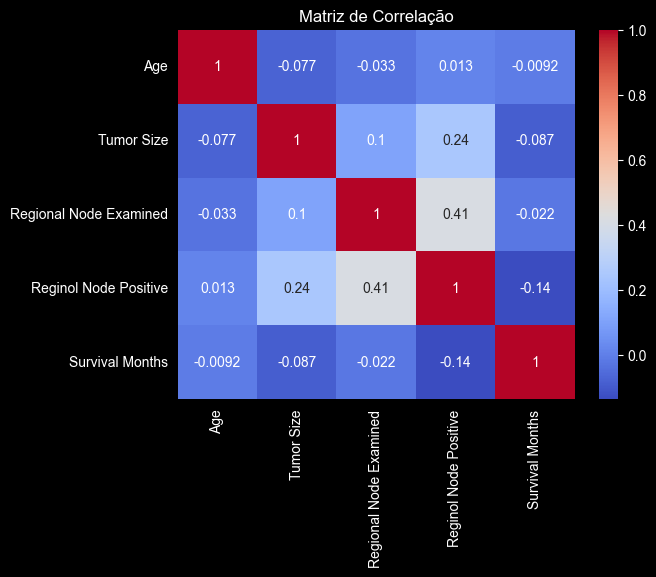

In [20]:
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Matriz de Correlação")
plt.savefig("../assets/charts_images/correlations/correlationMatriz.png", dpi=300, bbox_inches="tight")
plt.show()

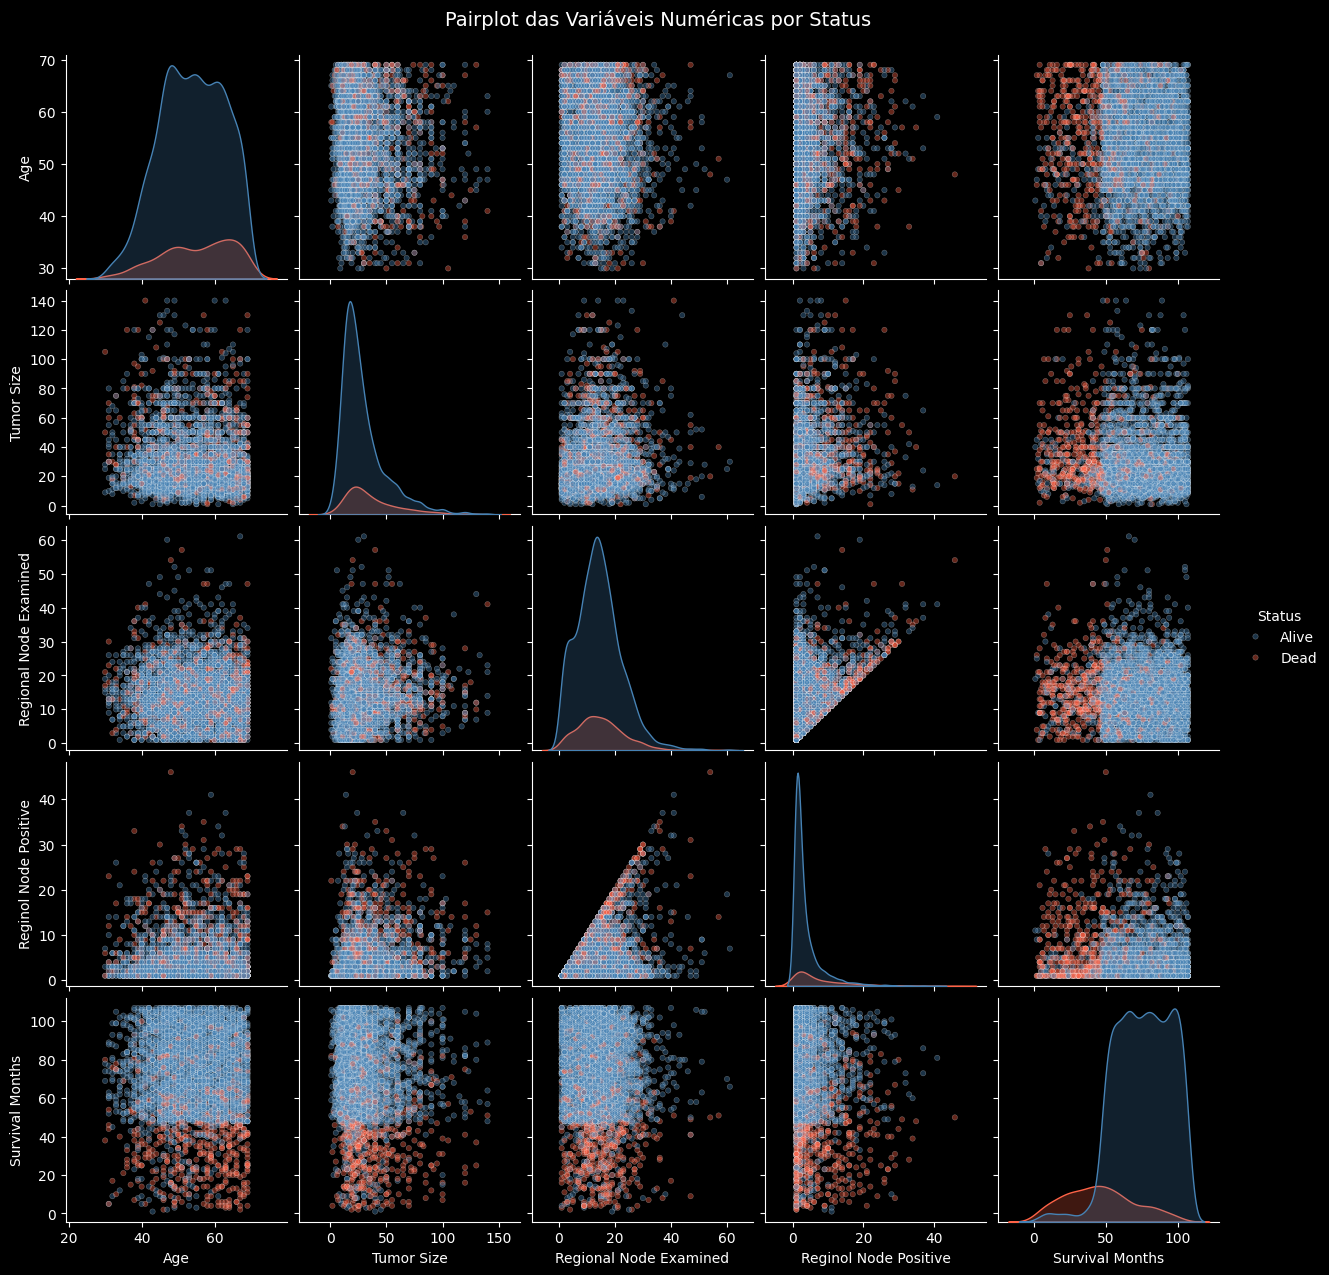

In [14]:
variaveis_numericas = [
    "Age",
    "Tumor Size",
    "Regional Node Examined",
    "Reginol Node Positive",
    "Survival Months"
]

palette_status = {"Alive": "steelblue", "Dead": "tomato"}

pairplot_fig = sns.pairplot(
    df[variaveis_numericas + ["Status"]],
    hue="Status",
    palette=palette_status,
    plot_kws={"alpha": 0.4, "s": 15},
    diag_kind="kde"
)

pairplot_fig.figure.suptitle("Pairplot das Variáveis Numéricas por Status", y=1.02, fontsize=14)
pairplot_fig.savefig("../assets/charts_images/correlations/pairplot_status.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()

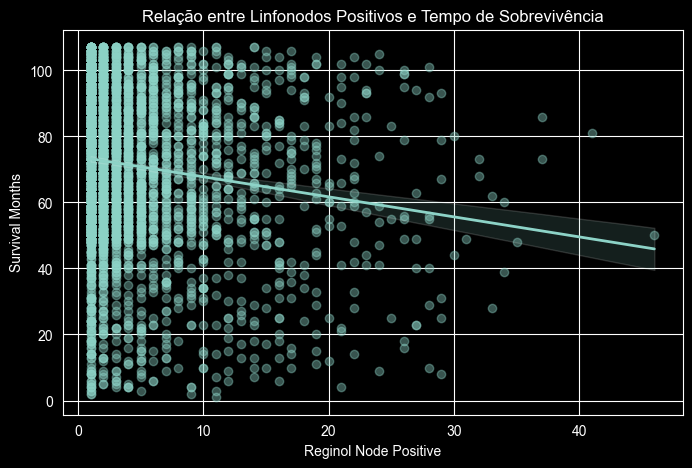

In [17]:
plt.figure(figsize=(8,5))

sns.regplot(
    x=df['Reginol Node Positive'],
    y=df['Survival Months'],
    scatter_kws={'alpha': 0.4},
    line_kws={'linewidth': 2}
)

plt.title("Relação entre Linfonodos Positivos e Tempo de Sobrevivência")
plt.xlabel("Reginol Node Positive")
plt.ylabel("Survival Months")
plt.savefig("../assets/charts_images/correlations/positiveLinfonodos.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
sns.scatterplot(
    x=df['Survival Months'],
    y=df['Tumor Size'],
)

plt.title("Tempo de sobrevivencia de acordo com o tamanho do tumor")
plt.savefig("../charts_images/tumorSizeSurvival.png", dpi=300, bbox_inches="tight")
plt.show()

### Visualização das Variáveis Categóricas

As variáveis categóricas analisadas foram: Race, Marital Status, T Stage, N Stage, 6th Stage, differentiate, Grade, A Stage, Estrogen Status, Progesterone Status e Status.

Os gráficos mostram predominância de estágios tumorais intermediários e diferença relevante entre os grupos de status hormonal.

Os heatmaps de proporção revelaram dois padrões importantes: no cruzamento **N Stage × Status**, a taxa de mortalidade aumenta progressivamente com o avanço do estágio nodal (N1 → menor mortalidade, N3 → maior);

No cruzamento **Grade × T Stage**, tumores de grau 1 concentram estágios iniciais (T1, T2) enquanto grau 3 concentra estágios avançados (T3, T4), evidenciando associação entre grau histológico e progressão tumoral.

In [ ]:
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.xticks(rotation=45)
    plt.tight_layout()
    file_name = col.replace(" ", "_")
    plt.savefig(f"../charts_images/variables_categoricals/{file_name}.png", dpi=300, bbox_inches="tight")
    plt.show()

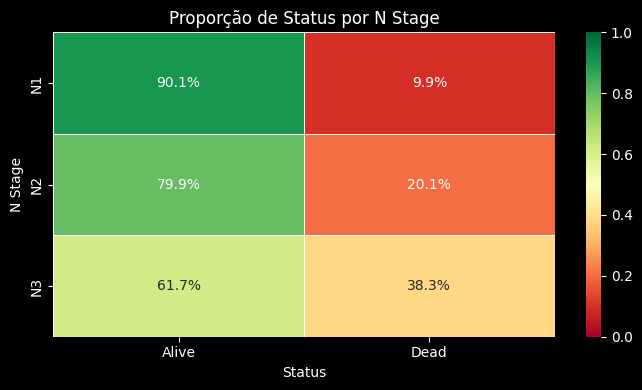

In [15]:
tabela_nstage_status = (
    df.groupby("N Stage")["Status"]
    .value_counts(normalize=True)
    .unstack()
    .sort_index()
)

plt.figure(figsize=(7, 4))
sns.heatmap(
    tabela_nstage_status,
    annot=True,
    fmt=".1%",
    cmap="RdYlGn",
    linewidths=0.5,
    vmin=0,
    vmax=1
)
plt.title("Proporção de Status por N Stage")
plt.xlabel("Status")
plt.ylabel("N Stage")
plt.tight_layout()
plt.savefig("../assets/charts_images/variables_categoricals/heatmap/heatmap_nstage_status.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

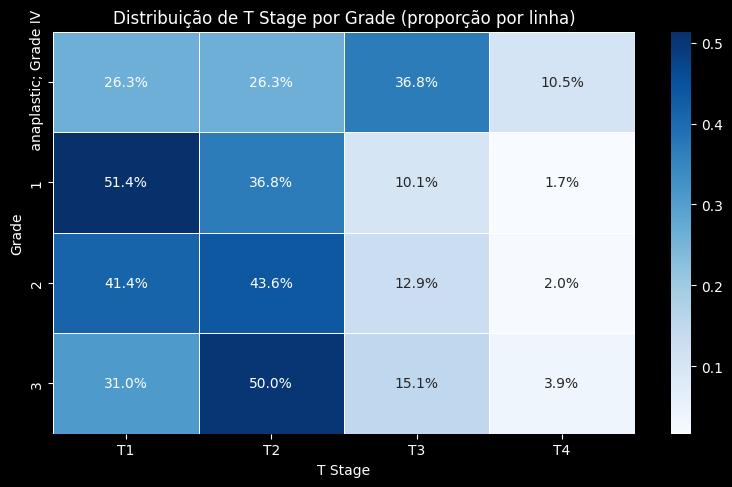

In [17]:
tabela_grade_tstage = (
    df.groupby("Grade")["T Stage "]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .reindex(columns=["T1", "T2", "T3", "T4"])
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    tabela_grade_tstage,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    linewidths=0.5
)
plt.title("Distribuição de T Stage por Grade (proporção por linha)")
plt.xlabel("T Stage")
plt.ylabel("Grade")
plt.tight_layout()
plt.savefig("../assets/charts_images/variables_categoricals/heatmap/heatmap_grade_tstage.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

### Distribuição das Variáveis

Os boxplots comparando **Alive vs Dead** mostraram:

**Age** sem diferença expressiva entre os grupos;

**Tumor Size** com mediana maior em pacientes que foram a óbito;

**Reginol Node Positive** com a diferença mais evidente — pacientes falecidos apresentaram mediana significativamente maior.

O **pairplot** confirmou que a separação entre os grupos é mais visível na combinação de **Reginol Node Positive e Survival Months**, e que nenhuma variável isolada separa completamente os grupos — o prognóstico é multifatorial.


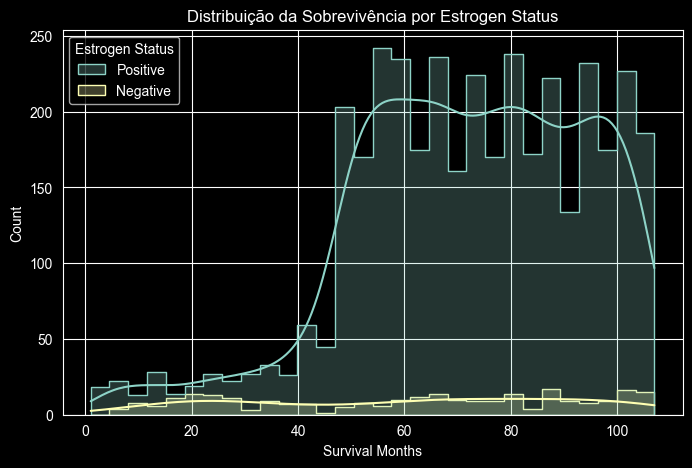

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Survival Months",
    hue="Estrogen Status",
    kde=True,
    bins=30,
    element="step"
)

plt.title("Distribuição da Sobrevivência por Estrogen Status")
plt.savefig("../charts_images/survivorEstrogenStatus.png", dpi=300, bbox_inches="tight")
plt.show()

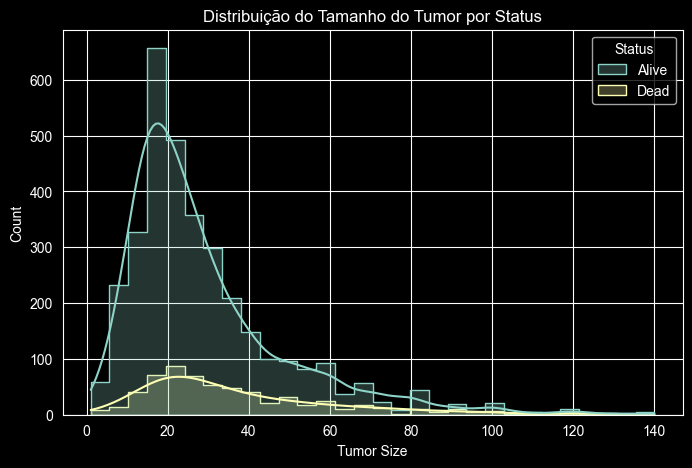

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Tumor Size",
    hue="Status",
    kde=True,
    bins=30,
    element="step"
)

plt.title("Distribuição do Tamanho do Tumor por Status")
plt.savefig("../charts_images/correlationTumorSizeStatus.png", dpi=300, bbox_inches="tight")
plt.show()

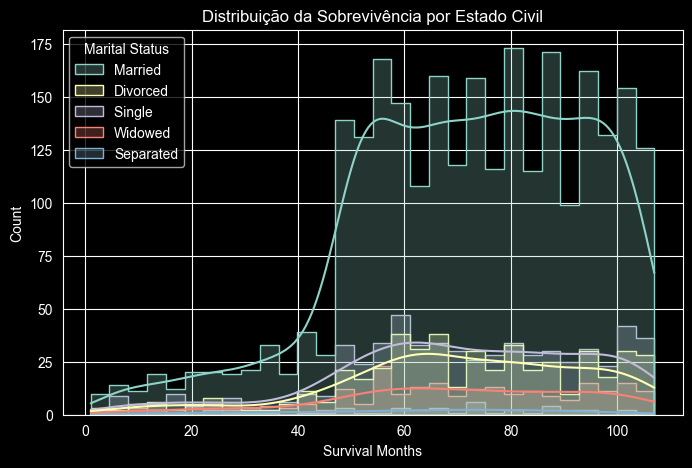

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Survival Months",
    hue="Marital Status",
    kde=True,
    bins=30,
    element="step"
)

plt.title("Distribuição da Sobrevivência por Estado Civil")
plt.savefig("../charts_images/averageMaritalStatusSurvival.png", dpi=300, bbox_inches="tight")
plt.show()

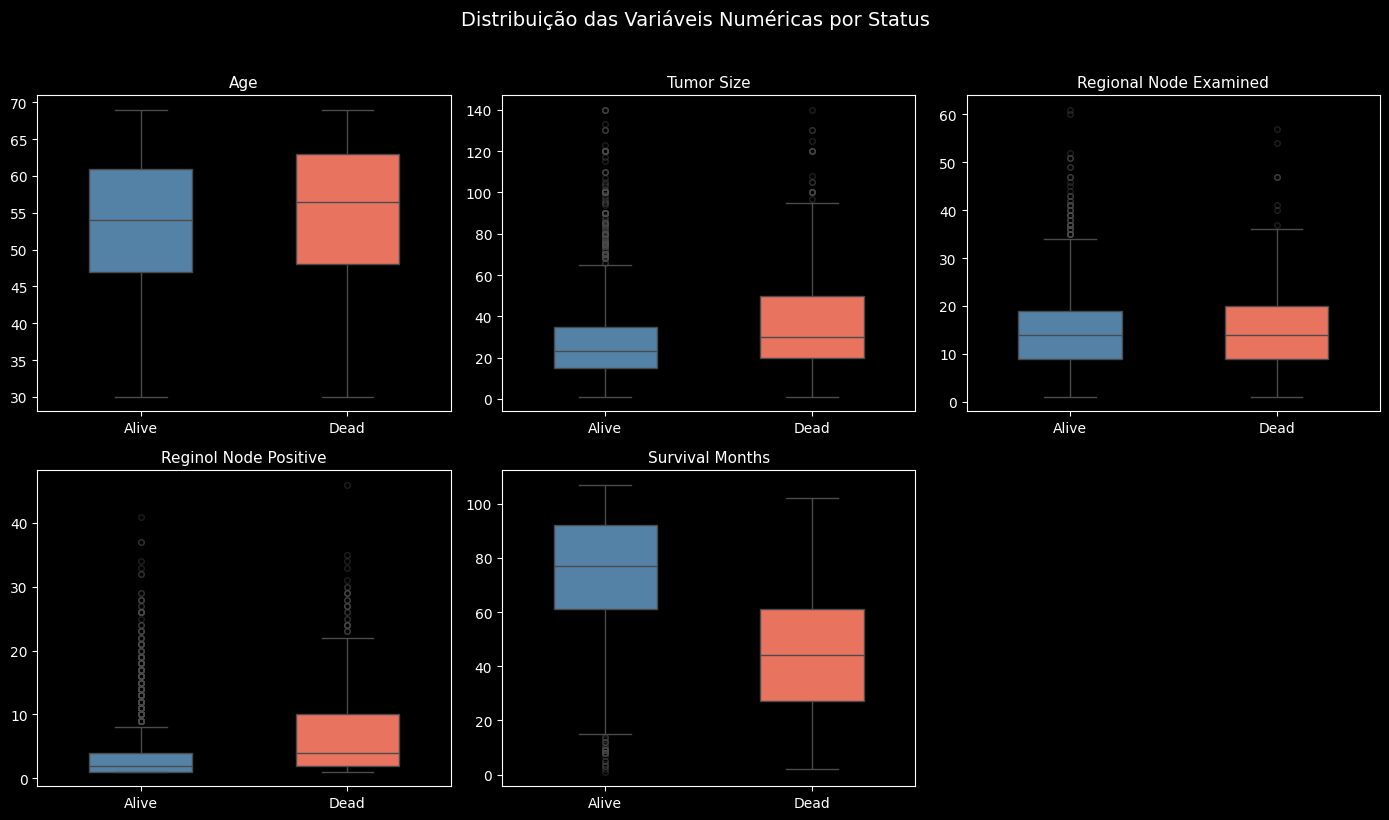

In [19]:
variaveis_numericas = [
    "Age",
    "Tumor Size",
    "Regional Node Examined",
    "Reginol Node Positive",
    "Survival Months"
]

palette_status = {"Alive": "steelblue", "Dead": "tomato"}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flatten(), variaveis_numericas):
    sns.boxplot(
        data=df,
        x="Status",
        y=col,
        hue="Status",
        palette=palette_status,
        ax=ax,
        width=0.5,
        legend=False,
        flierprops={"marker": "o", "alpha": 0.4, "markersize": 4}
)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Remover o subplot vazio (2x3 com 5 variáveis)
axes[1, 2].set_visible(False)

fig.suptitle("Distribuição das Variáveis Numéricas por Status", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../assets/charts_images/distributions/boxplot_numericas_status.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

### Formulação de Hipóteses

Foram testadas 6 hipóteses com nível de significância α = 0,05.

**H1** (Estrogen Status positivo → maior sobrevivência): confirmada — diferença de 11,79 meses a mais (p = 2,82e-16).

**H2** (pacientes que morreram tinham tumores maiores): confirmada — diferença média de 7,87mm (p = 1,24e-17).

**H3** (pacientes que morreram tinham mais linfonodos positivos): confirmada e mais expressiva — pacientes mortos tiveram em média o dobro de linfonodos positivos (p = 1,53e-61).

**H4** (Estrogen positivo → tumores menores): confirmada — diferença de 5,03mm (p = 1,56e-04).

**H5** (estágio do tumor influencia sobrevivência): confirmada — redução progressiva T1 > T2 > T3 > T4 (p = 8,36e-07).

**H6** (estado civil influencia sobrevivência): não confirmada — diferença de 1,56 meses sem significância estatística (p = 0,1248). Variável de baixo potencial preditivo.




In [42]:
print("Pacientes positivos sobrevivem mais?")

positivo = df[df["Estrogen Status"] == "Positive"]["Survival Months"]
negativo = df[df["Estrogen Status"] == "Negative"]["Survival Months"]

hipotese1 = stats.ttest_ind(positivo, negativo)

media_positivo = positivo.mean()
media_negativo = negativo.mean()

print("p-valor:", hipotese1.pvalue)
print("Média Positive:", media_positivo)
print("Média Negative:", media_negativo)

if hipotese1.pvalue < 0.05:
    print("Existe diferença significativa entre os grupos")

    if media_positivo > media_negativo:
        print("Pacientes positivos sobrevivem mais, em média")
    else:
        print("Pacientes negativos sobrevivem mais, em média")
else:
    print("Não existe diferença significativa entre os grupos")

Pacientes positivos sobrevivem mais?
p-valor: 2.8191768683102073e-16
Média Positive: 72.08601864181092
Média Negative: 60.29739776951673
Existe diferença significativa entre os grupos
Pacientes positivos sobrevivem mais, em média


In [43]:
print("Pacientes que morreram tinham tumores maiores?")

alive = df[df["Status"] == "Alive"]["Tumor Size"]
dead = df[df["Status"] == "Dead"]["Tumor Size"]

hipotese2 = stats.ttest_ind(alive, dead)

media_alive = alive.mean()
media_dead = dead.mean()

print("p-valor:", hipotese2.pvalue)
print("Média Alive:", media_alive)
print("Média Dead:", media_dead)

if hipotese2.pvalue < 0.05:
    print("Existe diferença significativa")
    if media_dead > media_alive:
        print("Pacientes que morreram tinham tumores maiores")
    else:
        print("Pacientes vivos tinham tumores maiores")
else:
    print("Não existe diferença significativa")

Pacientes que morreram tinham tumores maiores?
p-valor: 1.2377493765575529e-17
Média Alive: 29.268779342723004
Média Dead: 37.13961038961039
Existe diferença significativa
Pacientes que morreram tinham tumores maiores


In [44]:
print("Pacientes que morreram tinham mais linfonodos positivos?")

alive = df[df["Status"] == "Alive"]["Reginol Node Positive"]
dead = df[df["Status"] == "Dead"]["Reginol Node Positive"]

hipotese3 = stats.ttest_ind(alive, dead)

media_alive = alive.mean()
media_dead = dead.mean()

print("p-valor:", hipotese3.pvalue)
print("Média Alive:", media_alive)
print("Média Dead:", media_dead)

if hipotese3.pvalue < 0.05:
    print("Existe diferença significativa")
    if media_dead > media_alive:
        print("Pacientes que morreram tinham mais linfonodos positivos")
    else:
        print("Pacientes vivos tinham mais linfonodos positivos")
else:
    print("Não existe diferença significativa")

Pacientes que morreram tinham mais linfonodos positivos?
p-valor: 1.5290313935284383e-61
Média Alive: 3.6006455399061035
Média Dead: 7.241883116883117
Existe diferença significativa
Pacientes que morreram tinham mais linfonodos positivos


In [45]:
print("Pacientes positivos possuem tumores menores?")

positivo = df[df["Estrogen Status"] == "Positive"]["Tumor Size"]
negativo = df[df["Estrogen Status"] == "Negative"]["Tumor Size"]

hipotese4 = stats.ttest_ind(positivo, negativo)

media_positivo = positivo.mean()
media_negativo = negativo.mean()

print("p-valor:", hipotese4.pvalue)
print("Média Positive:", media_positivo)
print("Média Negative:", media_negativo)

if hipotese4.pvalue < 0.05:
    print("Existe diferença significativa")
    if media_positivo < media_negativo:
        print("Pacientes positivos possuem tumores menores")
    else:
        print("Pacientes negativos possuem tumores menores")
else:
    print("Não existe diferença significativa")

Pacientes positivos possuem tumores menores?
p-valor: 0.00015561625114507565
Média Positive: 30.13688415446072
Média Negative: 35.174721189591075
Existe diferença significativa
Pacientes positivos possuem tumores menores


In [49]:
print("O estágio do tumor influencia a sobrevivência?")

t1 = df[df["T Stage "] == "T1"]["Survival Months"]
t2 = df[df["T Stage "] == "T2"]["Survival Months"]
t3 = df[df["T Stage "] == "T3"]["Survival Months"]
t4 = df[df["T Stage "] == "T4"]["Survival Months"]

hipotese5 = stats.f_oneway(t1, t2, t3, t4)

print("p-valor:", hipotese5.pvalue)
print("Média T1:", t1.mean())
print("Média T2:", t2.mean())
print("Média T3:", t3.mean())
print("Média T4:", t4.mean())

if hipotese5.pvalue < 0.05:
    print("Existe diferença significativa entre os estágios")
else:
    print("Não existe diferença significativa")

O estágio do tumor influencia a sobrevivência?
p-valor: 8.362503589348084e-07
Média T1: 73.56394260761073
Média T2: 70.30123180291153
Média T3: 68.88555347091932
Média T4: 65.74509803921569
Existe diferença significativa entre os estágios


In [52]:
print("Pacientes casados sobrevivem mais?")

casado = df[df["Marital Status"] == "Married"]["Survival Months"]
solteiro = df[df["Marital Status"] == "Single "]["Survival Months"]

hipotese6 = stats.ttest_ind(casado, solteiro)

media_casado = casado.mean()
media_solteiro = solteiro.mean()

print("p-valor:", hipotese6.pvalue)
print("Média casados:", media_casado)
print("Média solteiros:", media_solteiro)

if hipotese6.pvalue < 0.05:
    print("Existe diferença significativa")
    if media_casado > media_solteiro:
        print("Pacientes casados sobrevivem mais")
    else:
        print("Pacientes solteiros sobrevivem mais")
else:
    print("Não existe diferença significativa")

Pacientes casados sobrevivem mais?
p-valor: 0.12477266010236526
Média casados: 71.97956867196368
Média solteiros: 70.42276422764228
Não existe diferença significativa
